
# test_frg_kernel

This notebook checks the temperature-flow-consistent one-loop kernels:
- `compute_pp_kernel`
- `compute_ph_kernel`
- `compute_phc_kernel`

It also compares them to the previous implementation, whose main issue was using
`S = dG/dT` alone and effectively dropping the explicit `d/dT` acting on the full
Matsubara bubble `T sum_n GG`.


In [2]:

import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass

from frg_kernel import (
    FlowConfig,
    compute_pp_kernel,
    compute_ph_kernel,
    compute_phc_kernel,
    bubble_dot_pp,
    bubble_dot_ph,
    fermionic_matsubara_frequencies,
    physical_propagator,
)


In [3]:

# Mock patch objects compatible with patching/channels/frg code
@dataclass
class MockPatch:
    k_cart: np.ndarray
    energy: float
    eigvec: np.ndarray

class MockPatchSet:
    def __init__(self, ks, energies, b1=None, b2=None, norb=3):
        self.patches = [MockPatch(np.asarray(k, float), float(e), np.ones(norb, dtype=complex)/np.sqrt(norb))
                        for k, e in zip(ks, energies)]
        self.Npatch = len(self.patches)
        self.b1 = np.asarray([2*np.pi, 0.0] if b1 is None else b1, float)
        self.b2 = np.asarray([0.0, 2*np.pi] if b2 is None else b2, float)


def make_patchsets(N=6):
    theta = np.linspace(0, 2*np.pi, N, endpoint=False)
    ks = np.c_[0.8*np.cos(theta), 0.8*np.sin(theta)]
    e_up = 0.15*np.cos(theta) - 0.03
    e_dn = 0.15*np.cos(theta + 0.2) + 0.02
    return {
        'up': MockPatchSet(ks, e_up),
        'dn': MockPatchSet(ks, e_dn),
    }

patchsets = make_patchsets(N=8)
Q = np.array([0.25, -0.15])
config = FlowConfig(temperature=0.12, nfreq=160)


In [4]:

# Build a deterministic complex mock antisymmetrized-looking vertex tensor.
# This is not meant to be fully physical; it is only for numerical regression tests.
spins = ['up', 'dn']
N = patchsets['up'].Npatch
rng = np.random.default_rng(7)

def make_block(scale=0.2):
    x = scale * (rng.normal(size=(N,N,N,N)) + 1j*rng.normal(size=(N,N,N,N)))
    # enforce antisymmetry in incoming and outgoing legs separately
    x = x - np.swapaxes(x, 0, 1)
    x = x - np.swapaxes(x, 2, 3)
    return x

gamma = {(s1,s2,s3,s4): make_block(scale=0.05 if (s1==s2==s3==s4) else 0.08)
         for s1 in spins for s2 in spins for s3 in spins for s4 in spins}


In [5]:

# New implementation
Kpp = compute_pp_kernel(gamma, patchsets, Q, incoming_spins=('up','dn'), outgoing_spins=('up','dn'), config=config)
Kph = compute_ph_kernel(gamma, patchsets, Q, incoming_spins=('up','up'), outgoing_spins=('up','up'), config=config)
Kphc = compute_phc_kernel(gamma, patchsets, Q, incoming_spins=('up','up'), outgoing_spins=('up','up'), config=config)

for name, K in [('pp', Kpp), ('ph', Kph), ('phc', Kphc)]:
    print(name, K.matrix.shape, np.max(np.abs(K.matrix)), np.linalg.norm(K.matrix))


pp (8, 8) 4.242252159113446 23.705052797032906
ph (8, 8) 7.473020144971135 27.061445762363086
phc (8, 8) 7.473020144971135 27.061445762363086


In [6]:

# Old bubble recipe for comparison: T sum_n [S G + G S] with S = dG/dT only
# This is the inconsistent choice we want to move away from.

def old_full_propagator(energy, T, nfreq):
    w = fermionic_matsubara_frequencies(T, nfreq)
    return 1.0 / (1j*w - energy)


def old_single_scale(energy, T, nfreq):
    n = np.arange(-nfreq, nfreq + 1, dtype=float)
    w = (2.0*n + 1.0)*np.pi*T
    dw_dT = (2.0*n + 1.0)*np.pi
    return -(1j*dw_dT) / (1j*w - energy)**2


def old_gs_pp(ea, eb, T, nfreq):
    G1 = old_full_propagator(ea, T, nfreq)
    G2 = 1.0 / (-1j*fermionic_matsubara_frequencies(T, nfreq) - eb)
    S1 = old_single_scale(ea, T, nfreq)
    n = np.arange(-nfreq, nfreq + 1, dtype=float)
    w = (2.0*n + 1.0)*np.pi*T
    dw_dT = (2.0*n + 1.0)*np.pi
    S2 = +(1j*dw_dT) / (-1j*w - eb)**2
    return T*np.sum(S1*G2 + G1*S2)


def old_gs_ph(ea, eb, T, nfreq):
    G1 = old_full_propagator(ea, T, nfreq)
    G2 = old_full_propagator(eb, T, nfreq)
    S1 = old_single_scale(ea, T, nfreq)
    S2 = old_single_scale(eb, T, nfreq)
    return T*np.sum(S1*G2 + G1*S2)

# Compare bubble derivatives directly on a representative pair
print('pp bubble new  :', bubble_dot_pp(0.03, -0.02, config))
print('pp bubble old  :', old_gs_pp(0.03, -0.02, config.temperature, config.nfreq))
print('ph bubble new  :', bubble_dot_ph(0.03, -0.02, config))
print('ph bubble old  :', old_gs_ph(0.03, -0.02, config.temperature, config.nfreq))


pp bubble new  : (-16.773806530881867+5.6427585528595607e-08j)
pp bubble old  : (-33.923568175522405+8.464138105068741e-08j)
ph bubble new  : (17.130108560339554-1.128551728735161e-08j)
ph bubble old  : (34.39935283064915-1.692827638066774e-08j)


In [7]:

# Scaling sanity: kernel should scale quadratically with Gamma
small_gamma = {k: 0.1*v for k, v in gamma.items()}
Kpp_small = compute_pp_kernel(small_gamma, patchsets, Q, incoming_spins=('up','dn'), outgoing_spins=('up','dn'), config=config)
ratio = np.linalg.norm(Kpp_small.matrix) / np.linalg.norm(Kpp.matrix)
print('Quadratic scaling ratio (expect ~0.01):', ratio)


Quadratic scaling ratio (expect ~0.01): 0.01


In [8]:

# Zero-interaction sanity
zero_gamma = {k: np.zeros_like(v) for k, v in gamma.items()}
K0 = compute_ph_kernel(zero_gamma, patchsets, Q, incoming_spins=('up','up'), outgoing_spins=('up','up'), config=config)
print('Zero-interaction max abs:', np.max(np.abs(K0.matrix)))


Zero-interaction max abs: 0.0


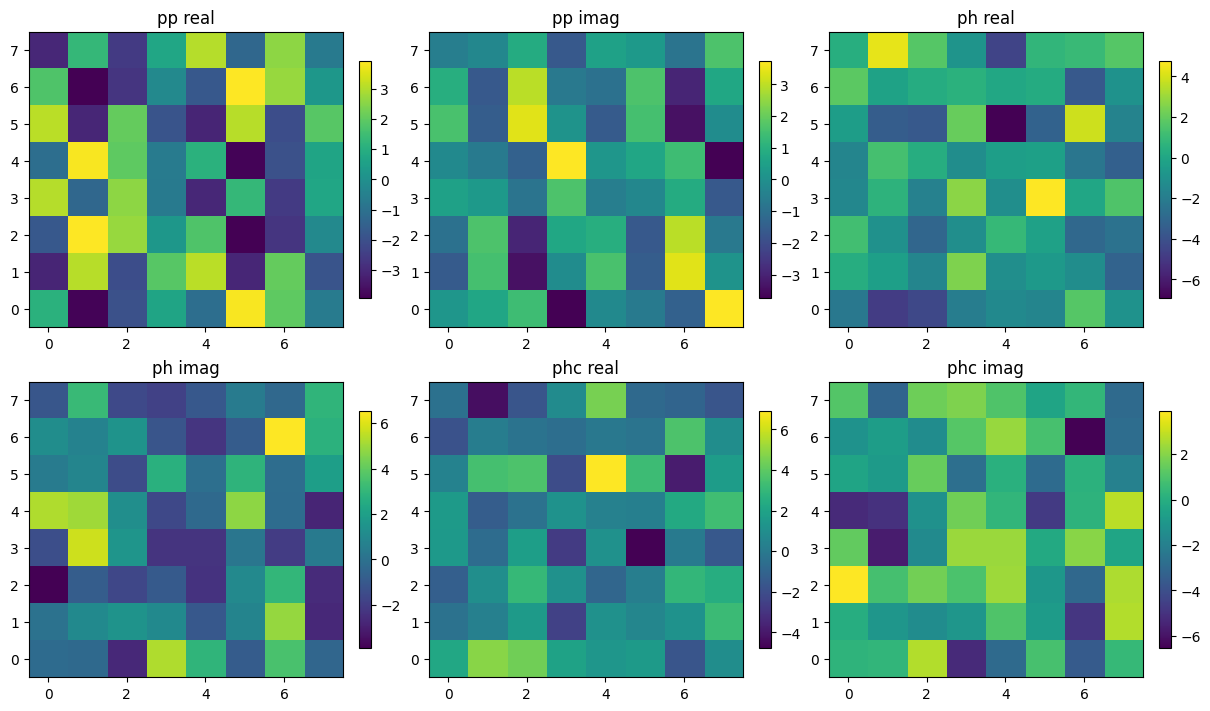

In [9]:

figs = [
    ('pp real', Kpp.matrix.real), ('pp imag', Kpp.matrix.imag),
    ('ph real', Kph.matrix.real), ('ph imag', Kph.matrix.imag),
    ('phc real', Kphc.matrix.real), ('phc imag', Kphc.matrix.imag),
]

fig, axes = plt.subplots(2, 3, figsize=(12, 7), constrained_layout=True)
for ax, (title, arr) in zip(axes.ravel(), figs):
    im = ax.imshow(arr, origin='lower', aspect='auto')
    ax.set_title(title)
    plt.colorbar(im, ax=ax, shrink=0.8)
plt.show()


In [10]:

# Compare norms against the old bubble choice on a minimal direct diagnostic
# (here just the bubble values; the full kernel difference follows from the same source)
new_pp = bubble_dot_pp(0.06, -0.03, config)
old_pp = old_gs_pp(0.06, -0.03, config.temperature, config.nfreq)
new_ph = bubble_dot_ph(0.06, -0.03, config)
old_ph = old_gs_ph(0.06, -0.03, config.temperature, config.nfreq)
print('relative diff pp =', abs(new_pp - old_pp) / max(abs(new_pp), 1e-14))
print('relative diff ph =', abs(new_ph - old_ph) / max(abs(new_ph), 1e-14))


relative diff pp = 1.0771969818330176
relative diff ph = 1.031322694411191
